In [1]:
import numpy as np
import pandas as pd
import networkx as nx

import matplotlib.pyplot as plt
import seaborn as sns

from simulator import MetapopulationSIRSolver
from cut_graph import EasyCutGraph

# Load global air traffic network

In [2]:
unit_mob = 200 # Unit mobility per routes

In [3]:
edgelist = pd.read_csv("data\\edgelist_symmetric.csv")
nodelist = pd.read_csv("data\\nodelist_connected.csv")

In [4]:
# Max. number of routes between two countries as mobility
edgelist["weight"] = edgelist["Max. Number of Routes"] * unit_mob 

In [5]:
nodelist = nodelist.set_index("ID")

node_attr_dict = {}

for i in nodelist.index:
    node_attr_dict[i] = {"country": nodelist.loc[i, "Label"], "population": nodelist.loc[i, "Population"]}

In [6]:
graph = nx.from_pandas_edgelist(edgelist, "Source", "Target", edge_attr="weight", create_using=EasyCutGraph)
nx.set_node_attributes(graph, node_attr_dict)

In [7]:
cut_graph = graph.get_edge_cut('uniform_random', 100, seed=0)

In [8]:
cut_graph.number_of_nodes()

225

In [10]:
cut_graph.number_of_edges()

2217

In [9]:
np.where(nodelist["Label"] == "China")[0][0]

41

# Test run for COVID-19

Basic reproduciton number: https://doi.org/10.3961/jpmph.20.076

Recovery time: 2 weeks

In [7]:
simulator = MetapopulationSIRSolver(graph)

In [8]:
basic_rep = 3.32
r_time = 28

result = simulator.terminal_simulation(basic_rep, r_time, 41, 5, 30, 3*365)
result["message"]

c:\Users\user\anaconda3\Lib\site-packages\scipy\integrate\_ivp\common.py:39: UserWarning: The following arguments have no effect for a chosen solver: `jac`.
  warn("The following arguments have no effect for a chosen solver: {}."


'The solver successfully reached the end of the integration interval.'

In [9]:
result2 = simulator.terminal_simulation(basic_rep, r_time, 41, 5, 30, 3*365, method='LSODA')
result2["message"]

'The solver successfully reached the end of the integration interval.'

In [10]:
from time import time

start_time = time()

for _ in range(100):
    result = simulator.terminal_simulation(3.32, 14, 41, 5, 30, 3*365, method='DOP853')

print(time() - start_time)

33.064879179000854


In [11]:
from time import time

start_time = time()

for _ in range(100):
    result2 = simulator.terminal_simulation(3.32, 14, 41, 5, 30, 3*365, method='LSODA')

print(time() - start_time)

51.11979126930237


## Time series

Text(0.5, 1.0, 'South Korea')

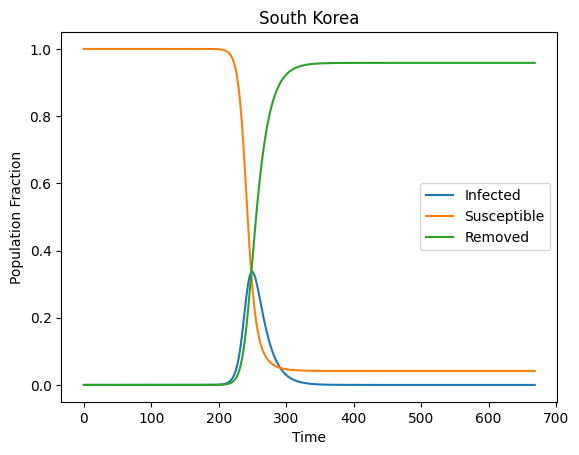

In [12]:
country = "South Korea"

node = np.where(nodelist["Label"] == country)[0][0]

plt.plot(result["t"], result["y"][node], label="Infected")
plt.plot(result["t"], result["y"][node + simulator.num_nodes], label="Susceptible")
plt.plot(result["t"], 1-result["y"][node]-result["y"][node + simulator.num_nodes], label="Removed")

plt.xlabel("Time")
plt.ylabel("Population Fraction")
plt.legend()
plt.title(country)

Text(0.5, 1.0, 'South Korea')

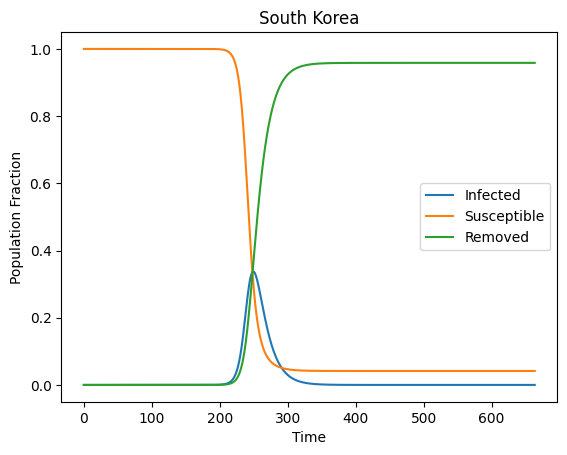

In [13]:
country = "South Korea"

node = np.where(nodelist["Label"] == country)[0][0]

plt.plot(result2["t"], result2["y"][node], label="Infected")
plt.plot(result2["t"], result2["y"][node + simulator.num_nodes], label="Susceptible")
plt.plot(result2["t"], 1-result2["y"][node]-result2["y"][node + simulator.num_nodes], label="Removed")

plt.xlabel("Time")
plt.ylabel("Population Fraction")
plt.legend()
plt.title(country)

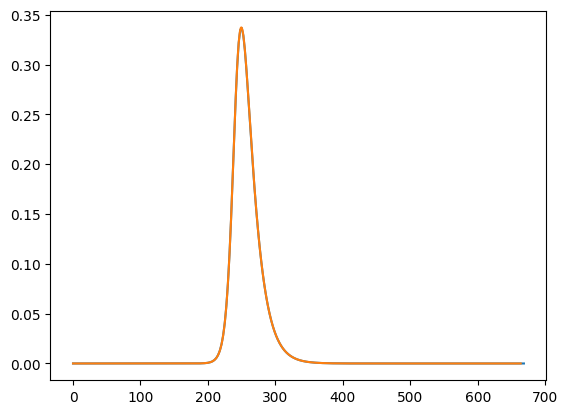

In [14]:
plt.plot(result["t"], result["y"][node], label="DOP853")
plt.plot(result2["t"], result2["y"][node], label="LSODA")

Text(0.5, 1.0, 'World')

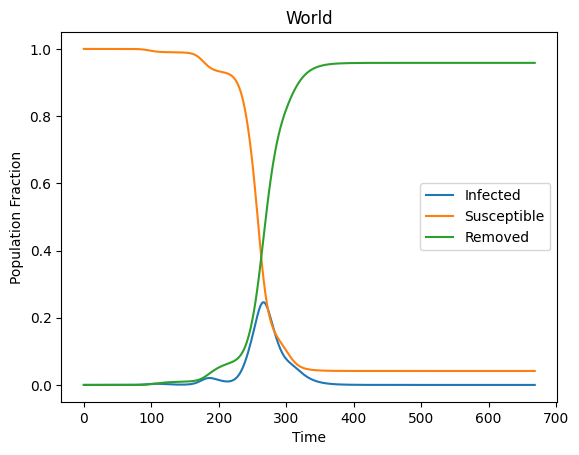

In [15]:
plt.plot(result["t"], result["I"].sum(axis=0) / simulator.total_pops.sum(), label="Infected")
plt.plot(result["t"], result["S"].sum(axis=0) / simulator.total_pops.sum(), label="Susceptible")
plt.plot(result["t"], result["R"].sum(axis=0) / simulator.total_pops.sum(), label="Removed")

plt.xlabel("Time")
plt.ylabel("Population Fraction")
plt.legend()
plt.title("World")

Text(0.5, 1.0, 'World')

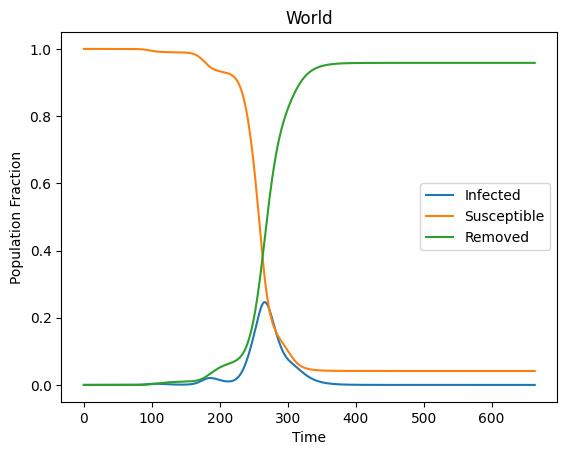

In [16]:
plt.plot(result2["t"], result2["I"].sum(axis=0) / simulator.total_pops.sum(), label="Infected")
plt.plot(result2["t"], result2["S"].sum(axis=0) / simulator.total_pops.sum(), label="Susceptible")
plt.plot(result2["t"], result2["R"].sum(axis=0) / simulator.total_pops.sum(), label="Removed")

plt.xlabel("Time")
plt.ylabel("Population Fraction")
plt.legend()
plt.title("World")

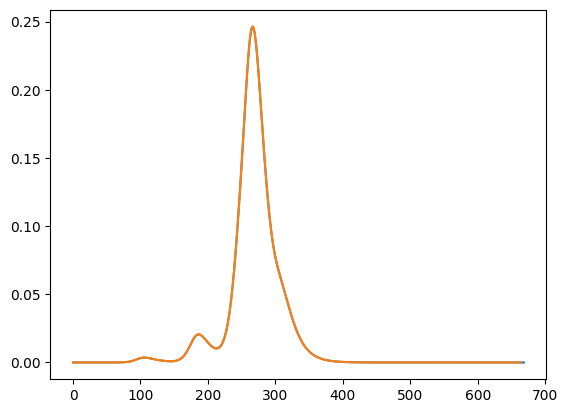

In [17]:
plt.plot(result["t"], result["I"].sum(axis=0) / simulator.total_pops.sum(), label="DOP853")
plt.plot(result2["t"], result2["I"].sum(axis=0) / simulator.total_pops.sum(), label="LSODA")

## Effective reproduction number

In [17]:
eff_reproduction1 = simulator.get_eff_rep(basic_rep=basic_rep, recovery_time=r_time)
eff_reproduction2 = simulator.get_eff_rep(basic_rep=basic_rep, recovery_time=r_time, sparse=True)

In [18]:
for _ in range(100):
    eff_reproduction1 = simulator.get_eff_rep(basic_rep=3.32, recovery_time=14)

In [19]:
for _ in range(100):
    eff_reproduction2 = simulator.get_eff_rep(basic_rep=3.32, recovery_time=14, sparse=True)

In [20]:
eff_reproduction1 - eff_reproduction2

-7.327471962526033e-14

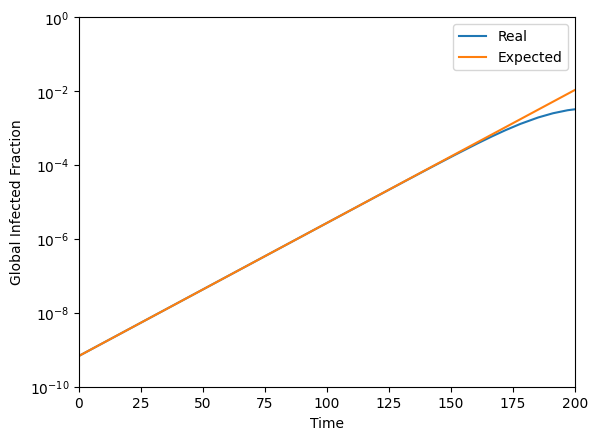

In [22]:
# Compare expectation with actual dynamics

global_i_frac = result["I"].sum(axis=0) / simulator.total_pops.sum()

plt.plot(result["t"], global_i_frac, label="Real")
plt.plot(result["t"], global_i_frac[0] * np.exp(((eff_reproduction2 - 1) / r_time * result["t"])), label="Expected")

plt.yscale('log')
plt.ylim((1e-10, 1))
plt.xlim((0, 200))

plt.xlabel("Time")
plt.ylabel("Global Infected Fraction")
plt.legend()

## Peaks

In [15]:
peaks = []

for node in graph.nodes:
    peaks.append(pd.DataFrame({
        "Country": [graph.nodes[node]["country"]],
        "Peak Severity": [result["y"][node].max()],
        "Peak Time": [result["t"][result["y"][node].argmax()]]
    }))

peaks = pd.concat(peaks)

In [16]:
peaks.sort_values(by="Peak Time", ascending=True)

,Country,Peak Severity,Peak Time
0,China,0.336537,104.916838
0,Chile,0.334953,131.393066
0,French Guiana,0.334065,134.124769
0,Australia,0.325791,139.275972
0,Zambia,0.335924,139.275972
...,...,...,...
0,Pakistan,0.335771,202.583759
0,Bolivia,0.336385,205.169003
0,Palau,0.334674,205.169003
0,Bahamas,0.333348,207.995307


In [17]:
peaks.sort_values(by="Peak Severity", ascending=True)

,Country,Peak Severity,Peak Time
0,Nauru,0.308839,172.341591
0,Brunei,0.312287,176.841792
0,Saudi Arabia,0.317432,156.597810
0,Afghanistan,0.318631,172.341591
0,Uganda,0.318772,165.596876
...,...,...,...
0,Central African Republic,0.336606,181.352864
0,Cameroon,0.336652,172.341591
0,Cape Verde,0.336682,195.181753
0,Belgium,0.336724,188.106500


c:\Users\user\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\user\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\user\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\user\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categor

Text(37.722222222222214, 0.5, 'Peak severity (Maximum infected fraction)')

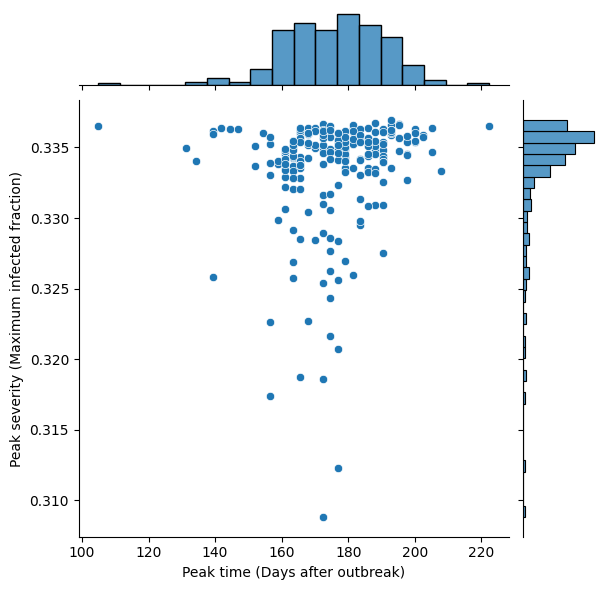

In [18]:
sns.jointplot(data=peaks, x="Peak Time", y="Peak Severity", kind="scatter")

plt.xlabel("Peak time (Days after outbreak)")
plt.ylabel("Peak severity (Maximum infected fraction)")

In [19]:
result["t"][-1] / len(result["t"])

5.586516088204297

# Animation

In [11]:
result = simulator.unit_time_simulation(3.32, 14, 41, 5, 600, 1)
result["message"]

'The solver successfully reached the end of the integration interval.'

In [12]:
from pickle import dump

with open("data\\covid19-test2_solver.pkl", 'wb') as f:
    dump(result, f)